In [1]:
import uproot
import os
import dask_awkward as dak
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import PercentFormatter, FormatStrFormatter
import mplhep as hep
from dask.diagnostics import ProgressBar
import xgboost as xgb
import optuna
import cupy as cp
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import joblib

import uproot
import awkward as ak
import dask_awkward as dak
import pandas as pd
import numpy as np
import os
import joblib
import json
import warnings
from dask.diagnostics import ProgressBar

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, learning_curve)
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score, 
                             confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score)

import zfit
from zfit.loss import UnbinnedNLL
from zfit.minimize import Minuit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mplhep as hep

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
plt.style.use(hep.style.CMS)

In [3]:
tree_path = "Events"
data_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022C.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022D.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022E.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022F.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022G.root"
]}

mc_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_signal_2022.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_signal_2022EE.root"
]}

In [4]:
def get_b0_truth_mask(df):
    # --- 1. Constantes PDG ---
    PDG_B0        = 511
    PDG_KSTAR     = 313
    PDG_KAON_plus = 321
    PDG_PION_neg  = -211
    PDG_MUON_plus = -13
    PDG_MUON_neg  = 13
    PDG_PHOTON    = 22

    mu1_idx  = df["BPH_1Muon_genPartIdx"]
    mu2_idx  = df["BPH_2Muon_genPartIdx"]
    trk1_idx = df["Trk1_genPartIdx"]
    trk2_idx = df["Trk2_genPartIdx"]

    # Verificação de Identidade (PDG ID)
    mu1_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mu2_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu2_idx, mu2_idx >= 0)]
    trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(trk1_idx, trk1_idx >= 0)]
    trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(trk2_idx, trk2_idx >= 0)]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    # Linhagem do Hadron (K, Pi -> K* -> B0)
    mom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk1_idx, trk1_idx >= 0)]
    mom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk2_idx, trk2_idx >= 0)]
    
    mom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    mom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    # K e Pi devem vir do mesmo objeto K*0
    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)
    
    # O K*0 deve vir de um B0
    gmom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    gmom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    gmom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
    gmom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]
    
    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    mom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu2_idx, mu2_idx >= 0)]
    mom_mu1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    mom_mu2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]
    
    gmom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    gmom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

    # Muon 1: Mae e o B0 do hadron OU (Mae e foton e Avo e o B0 do hadron)
    mu1_from_same_b0 = (mom_mu1_idx == gmom_trk1_idx) | \
                       ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu1_idx == gmom_trk1_idx))

    mu2_from_same_b0 = (mom_mu2_idx == gmom_trk1_idx) | \
                       ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_idx == gmom_trk1_idx))

    # --- Mascara Final ---
    full_mask = flavor_match & match_kstar & match_kstar_to_b0 & \
                mu1_from_same_b0 & mu2_from_same_b0
    
    return ak.fill_none(full_mask, False)

In [5]:
def add_derived_columns(df):
    df["BToTrkTrkMuMu_l_xy_sig"]   = df['BToTrkTrkMuMu_l_xy']    / df['BToTrkTrkMuMu_l_xy_unc']
    df["BToTrkTrkMuMu_dca_sig"]    = df['BToTrkTrkMuMu_dca']     / df['BToTrkTrkMuMu_dcaErr']
    df["BToTrkTrkMuMu_trk1_dca_sig"] = df['BToTrkTrkMuMu_trk1_dca'] / df['BToTrkTrkMuMu_trk1_dcaErr']
    df["BToTrkTrkMuMu_trk2_dca_sig"] = df['BToTrkTrkMuMu_trk2_dca'] / df['BToTrkTrkMuMu_trk2_dcaErr']
    return df

In [6]:
def apply_selection(df, mode="mc"):

    kstar_pdg = 0.892
    mask_kpi_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) <= 0.150
    mask_pik_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg) <= 0.150
    is_kpi_closer = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) < \
                    abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg)
    
    mask = (
        # Filtro de massa de dimuons (regiões de sinal, excluindo J/psi e Psi2S)
        (((df['MuMu_mass'] > 1.0) & (df['MuMu_mass'] < 2.7)) | 
         ((df['MuMu_mass'] > 4.0) & (df['MuMu_mass'] < 6.0))) & 
        
        # Pelo menos uma das combinações deve estar na janela de 3 sigma
        (mask_kpi_window | mask_pik_window) & 
        
        # Aplicamos a lógica de decisão de sabor (escolhemos a hipótese Kpi se ela for a melhor)
        (is_kpi_closer) &
        
        # Trigger e cortes cinemáticos dos múons
        (df['HLT_DoubleMu4_3_LowMass'] == 1) & 
        (df['BPH_1Muon_pt'] > 2.0) & (df['BPH_2Muon_pt'] > 2.0) & 
        (abs(df['BPH_1Muon_eta']) < 2.4) & (abs(df['BPH_2Muon_eta']) < 2.4) &
        (df['BToTrkTrkMuMu_fit_trk1_pt'] > 1.5) &
        (df['BToTrkTrkMuMu_fit_trk2_pt'] > 1.5) 
    )
    if mode == "mc":
        mask = mask & (df['BToTrkTrkMuMu_fit_mass_Kpi'] >= 5.1251) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] <= 5.4351)
        mask = mask & get_b0_truth_mask(df) # No MC junta a mask de thruth Matching !!!
    else:
        mask = mask & (
            ((df['BToTrkTrkMuMu_fit_mass_Kpi'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] < 5.1251)) | 
            ((df['BToTrkTrkMuMu_fit_mass_Kpi'] > 5.4351) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] < 5.6))
        )
    
    if mode == "mc":
        cols_to_keep = [
            'BToTrkTrkMuMu_l_xy_sig', 'BToTrkTrkMuMu_dca_sig',
            'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig',
            'BToTrkTrkMuMu_fit_ditrack_mass_Kpi',
            'BToTrkTrkMuMu_fit_pt', 'BToTrkTrkMuMu_fit_cos2D', 'BToTrkTrkMuMu_svprob',
            'event', 'Pileup_nTrueInt', 'BToTrkTrkMuMu_fit_mass_Kpi'
        ]
    else:
        cols_to_keep = [
            'BToTrkTrkMuMu_l_xy_sig', 'BToTrkTrkMuMu_dca_sig',
            'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig',
            'BToTrkTrkMuMu_fit_ditrack_mass_Kpi',
            'BToTrkTrkMuMu_fit_pt', 'BToTrkTrkMuMu_fit_cos2D', 'BToTrkTrkMuMu_svprob',
            'event', 'BToTrkTrkMuMu_fit_mass_Kpi'
        ]
        
    return df[cols_to_keep][mask]

In [7]:
def build_dataframe(file_dict, label="Dataset", mode="mc"):
    print(f"\nProcessando {label}...")

    df = uproot.dask(file_dict)
    df = add_derived_columns(df)
    df = apply_selection(df, mode=mode)

    with ProgressBar():
        awkward_array = df.compute()
        df_pandas = ak.to_dataframe(awkward_array).reset_index(drop=True)

    initial_len = len(df_pandas)
    df_pandas = df_pandas.replace([np.inf, -np.inf], np.nan)
    df_pandas = df_pandas.dropna()
    final_len  = len(df_pandas)
    removed    = initial_len - final_len

    if removed > 0:
        print(f"  [Limpeza] Removidos {removed} eventos com NaN ou Inf ({removed/initial_len:.2%})")

    print(f"{label} finalizado. Linhas: {final_len}")
    return df_pandas

In [8]:
df_data = build_dataframe(data_files, "Data (Sidebands)", mode="data")
df_mc   = build_dataframe(mc_files,   "MC Signal (Truth Matched)", mode="mc")

print(f"\nEventos de background (sidebands): {len(df_data)}")
print(f"Eventos de sinal (MC truth):        {len(df_mc)}")
print(f"Razao bkg/sig: {len(df_data)/len(df_mc):.1f}")


Processando Data (Sidebands)...
[########################################] | 100% Completed | 1.04 sms
[                                        ] | 0% Completed | 82.81 sms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 11m 28s
  [Limpeza] Removidos 2 eventos com NaN ou Inf (0.00%)
Data (Sidebands) finalizado. Linhas: 88915

Processando MC Signal (Truth Matched)...
[########################################] | 100% Completed | 312.56 ms
[                                        ] | 0% Completed | 37.46 sms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 50.30 s
  [Limpeza] Removidos 37 eventos com NaN ou Inf (0.02%)
MC Signal (Truth Matched) finalizado. Linhas: 185126

Eventos de background (sidebands): 88915
Eventos de sinal (MC truth):        185126
Razao bkg/sig: 0.5


In [9]:
pu_weight_arr = np.load("/eos/user/t/tdeandra/SWAN_projects/BPH_Analysis/MC_Analysis/Pileup_Correction/mc_weight.npy")

bins       = np.floor(df_mc['Pileup_nTrueInt'] + 0.5).astype(int)
valid_mask = (bins >= 0) & (bins < len(pu_weight_arr))

df_mc['pu_weight'] = 1.0
df_mc.loc[valid_mask, 'pu_weight'] = pu_weight_arr[bins[valid_mask]]
df_mc = df_mc.drop(columns=['Pileup_nTrueInt'])

In [10]:
df_data['pu_weight'] = 1.0

In [11]:
df_mc['total_weight']   = df_mc['pu_weight'] # x outros SFs (ID, HLT, etc.) quando disponiveis
df_data['total_weight'] = 1.0                 # Aqui não há correção 

In [12]:
df_data["label"] = 0  # background
df_mc["label"]   = 1  # sinal

In [13]:
df_combined = pd.concat([df_data, df_mc], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)
df_combined['fold_id'] = df_combined['event'] % 5

In [14]:
# features disponiveis que vou usar
features = [
    'BToTrkTrkMuMu_l_xy_sig',
    'BToTrkTrkMuMu_dca_sig',
    'BToTrkTrkMuMu_trk1_dca_sig',
    'BToTrkTrkMuMu_trk2_dca_sig',
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi',
    'BToTrkTrkMuMu_fit_pt',
    'BToTrkTrkMuMu_fit_cos2D',
    'BToTrkTrkMuMu_svprob',
]

In [15]:
meus_modelos = {}

for i in range(5):
    nome_arquivo = f"xgboost_fold_{i}.joblib"
    caminho_completo = os.path.join("bdt_models_final", nome_arquivo)    
    meus_modelos[f"modelo_{i}"] = joblib.load(caminho_completo)

In [16]:
dfs_processados = []

for i in range(5):
    df_temp = df_combined[df_combined["fold_id"] == i].copy()
    probs = meus_modelos[f"modelo_{i}"].predict_proba(df_temp[features])[:, 1]    
    df_temp['bdt_score'] = probs    
    dfs_processados.append(df_temp)
    print(f"Fold {i} processado.")

df_final = pd.concat(dfs_processados, ignore_index=True)

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [17:11:26] WARNING: /build/jenkins/workspace/lcg_release_pipeline/build/pyexternals/xgboost-2.1.3/src/xgboost/2.1.3/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Fold 0 processado.
Fold 1 processado.
Fold 2 processado.
Fold 3 processado.
Fold 4 processado.


In [17]:
df = df_final

Eventos esperados: 346786.84
Scale Factor: 0.0136


FileNotFoundError: [Errno 2] No such file or directory: 'PlotsEE/Comparrison_dataSideband_mcSignal_lumiscale.png'

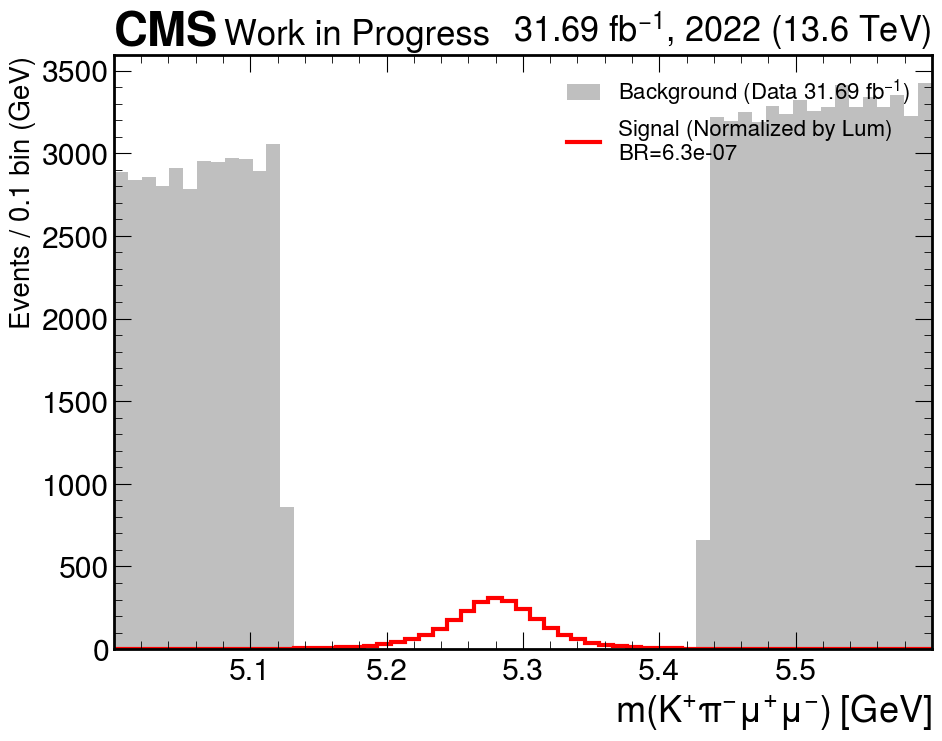

In [18]:
L_data_fb = 31.69
sigma_pb  = 17370000 
BR        = 6.30e-7
N_mc_gen  = 19906620 + 5542508            

L_data_pb = L_data_fb * 1000 
n_expected = L_data_pb * sigma_pb * BR
scale_factor = n_expected / N_mc_gen

print(f"Eventos esperados: {n_expected:.2f}")
print(f"Scale Factor: {scale_factor:.4f}")

var_name = 'BToTrkTrkMuMu_fit_mass_Kpi'
corte_bdt = 0.

mask_bkg = (df['label'] == 0) & (df['bdt_score'] > corte_bdt)
data_bkg = df[mask_bkg][var_name]

mask_sig = (df['label'] == 1) & (df['bdt_score'] > corte_bdt)
data_sig = df[mask_sig][var_name]

xmin, xmax = data_bkg.min(), data_bkg.max() 
bins = np.linspace(xmin, xmax, 60)
h_bkg, _ = np.histogram(data_bkg, bins=bins)

weights_sig = np.full(len(data_sig), scale_factor)
h_sig, _ = np.histogram(data_sig, bins=bins, weights=weights_sig)
fig, ax = plt.subplots(figsize=(10, 8))

hep.histplot(h_bkg, bins=bins, ax=ax, histtype='fill', color='gray', alpha=0.5, edgecolor='black',
    label=f'Background (Data {L_data_fb} fb$^{{-1}}$)')

hep.histplot(h_sig, bins=bins, ax=ax, histtype='step', linewidth=3, color='red',
             label=f'Signal (Normalized by Lum)\nBR={BR:.1e}')

#ax.set_xlabel(var_name.replace('_', ' '), fontsize=20)
ax.set_xlabel(r'$m(K^{+}\pi^{-}\mu^{+}\mu^{-})\;[\mathrm{GeV}]$')
ax.set_ylabel(f"Events / 0.1 bin (GeV)", fontsize=20)
ax.set_xlim(xmin, xmax)
ax.legend(loc='upper right', fontsize=16)
texts = hep.label.exp_label(
    exp="CMS",
    label="Work in Progress",
    data=True,
    lumi=L_data_fb,
    year=2022,
    com=13.6,
    ax=ax
)
texts[1].set_fontsize(25) 

plt.tight_layout()
plt.savefig("PlotsEE/Comparrison_dataSideband_mcSignal_lumiscale.png")
plt.show()

/tmp/ipykernel_338/2864239040.py:22: DeprecationWarning: __add__ (from zfit.core.space) is deprecated and will be removed in a future version.
Instructions for updating:
Multiple limits won't be supported anymore in the future. For alternatives, see the announcement: https://github.com/zfit/zfit/discussions/533
  obs_bkg = obs_lsb + obs_rsb
/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


Resultado do Fit Fold 0:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f0, lambda_bkg_f0]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17730, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00033 │        -20398.24 |  9766.363 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f0            0.226871  +/-   0.034       False


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


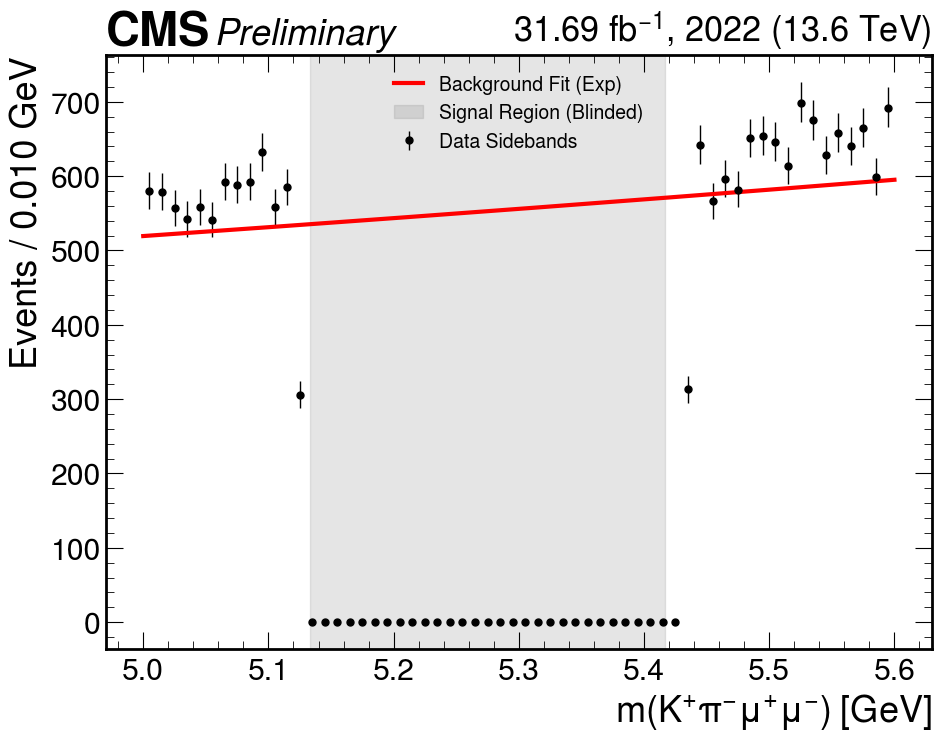

Iniciando BDT Scan para Fold 0...
Resultado do Fit Fold 1:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f1, lambda_bkg_f1]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17738, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00052 │        -20428.14 |  9707.462 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f1            0.314577  +/-   0.034       False


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


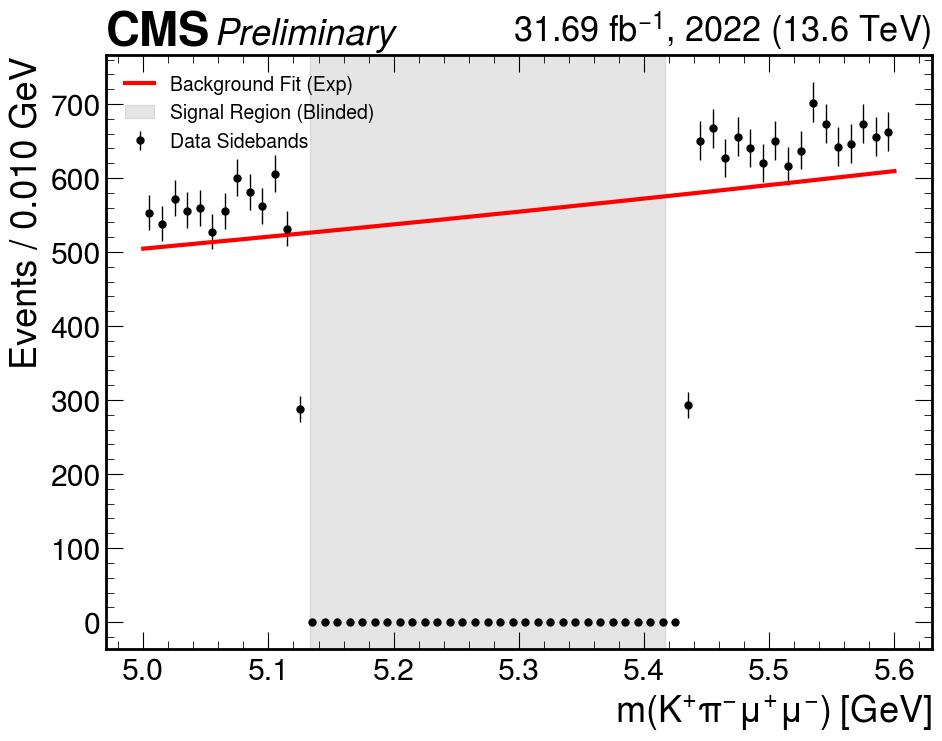

Iniciando BDT Scan para Fold 1...
Resultado do Fit Fold 2:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f2, lambda_bkg_f2]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17727, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00039 │        -20401.84 |  9744.909 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f2            0.260056  +/-   0.034       False


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


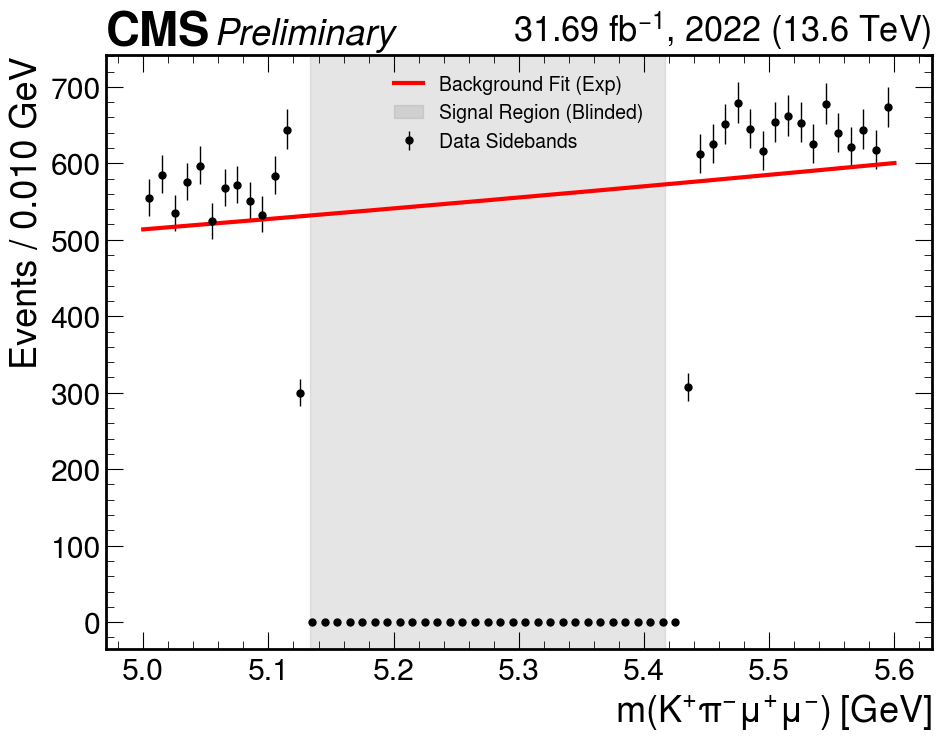

Iniciando BDT Scan para Fold 2...
Resultado do Fit Fold 3:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f3, lambda_bkg_f3]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17830, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00045 │        -20525.90 |  9727.809 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f3            0.283206  +/-   0.034       False


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


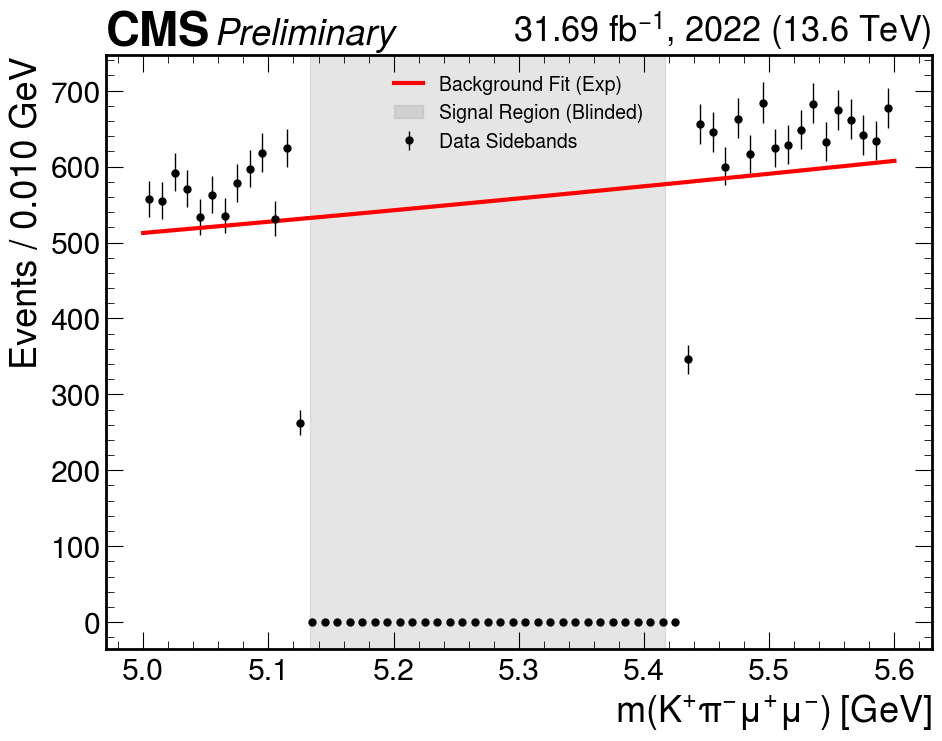

Iniciando BDT Scan para Fold 3...
Resultado do Fit Fold 4:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f4, lambda_bkg_f4]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17890, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00037 │        -20586.26 |  9751.997 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f4            0.245795  +/-   0.034       False


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


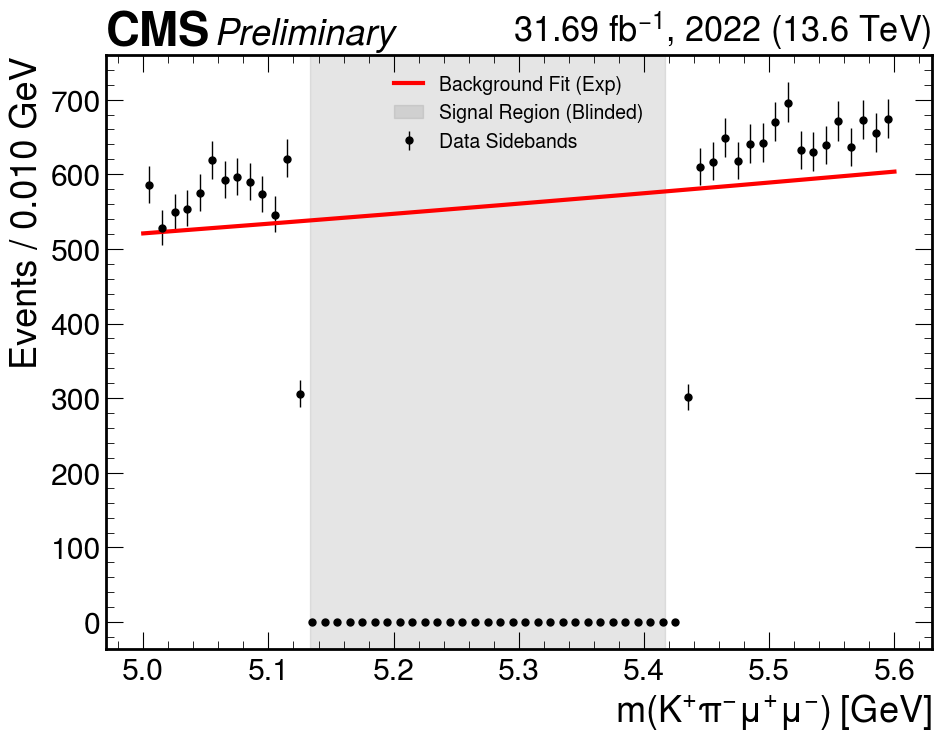

Iniciando BDT Scan para Fold 4...


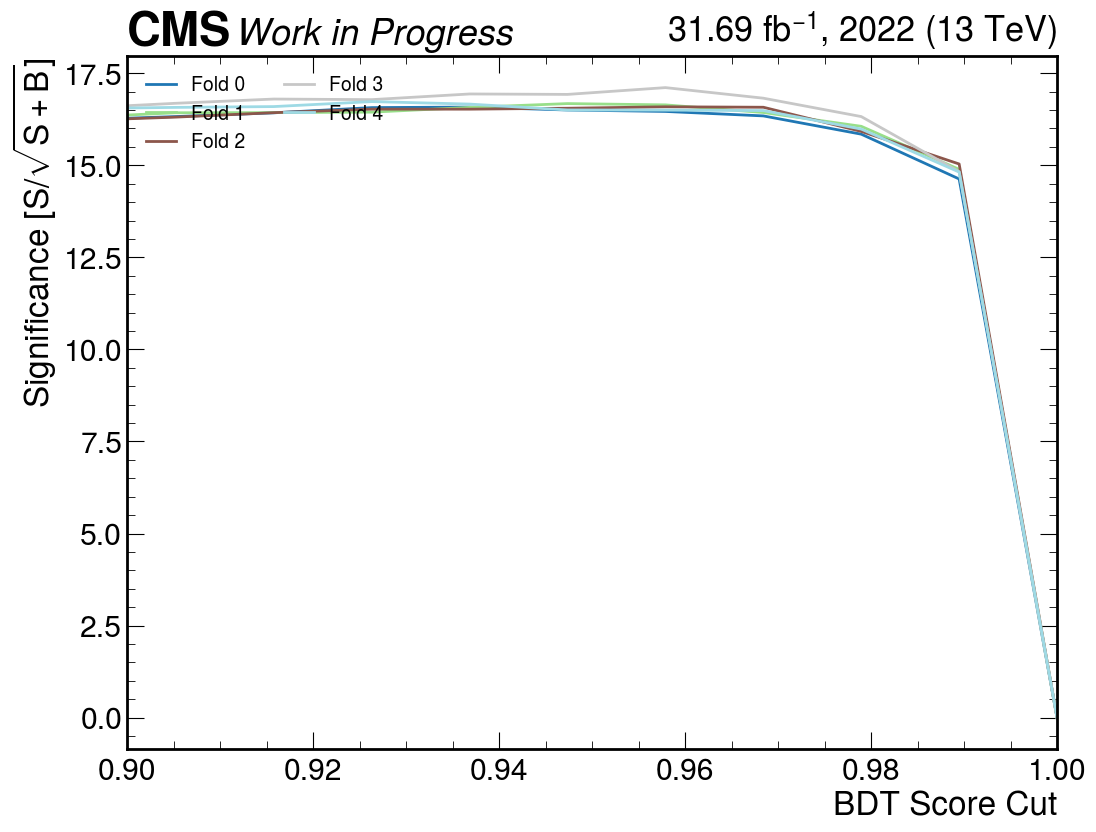

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import zfit
from zfit.loss import UnbinnedNLL
from zfit.minimize import Minuit 
import mplhep as hep
import os

if not os.path.exists("PlotsEE"):
    os.makedirs("PlotsEE")

all_fom_curves = []
all_cuts = np.linspace(0.8, 1, 20)

for i in range(5):
    df = df_final[df_final["fold_id"] == i]
    mass_min_lsb, mass_max_lsb = 5.0, 5.133542769
    mass_min_rsb, mass_max_rsb = 5.416657231, 5.6
    
    obs_lsb = zfit.Space("BToTrkTrkMuMu_fit_mass_Kpi", limits=(mass_min_lsb, mass_max_lsb))
    obs_rsb = zfit.Space("BToTrkTrkMuMu_fit_mass_Kpi", limits=(mass_min_rsb, mass_max_rsb))
    obs_bkg = obs_lsb + obs_rsb
    
    # Usando EXATAMENTE o corte_bdt que você definiu
    mask_sidebands = (df['label'] == 0) & (df['bdt_score'] > corte_bdt)
    data_sidebands_np = df[mask_sidebands]['BToTrkTrkMuMu_fit_mass_Kpi'].to_numpy()
    
    data_zfit = zfit.Data.from_numpy(obs=obs_bkg, array=data_sidebands_np)

    lambda_bkg = zfit.Parameter(f"lambda_bkg_f{i}", -0.5, -10.0, 100.0)
    bkg_model = zfit.pdf.Exponential(lambda_=lambda_bkg, obs=obs_bkg)
    
    loss = UnbinnedNLL(model=bkg_model, data=data_zfit)
    minimizer = Minuit()
    result = minimizer.minimize(loss)
    
    result.hesse()
    print(f"Resultado do Fit Fold {i}:\n{result}")

    plt.figure(figsize=(10, 8))
    nbins = 60
    counts, bin_edges = np.histogram(data_sidebands_np, bins=nbins, range=(mass_min_lsb, mass_max_rsb))
    bin_width = bin_edges[1] - bin_edges[0]
    
    hep.histplot(counts, bins=bin_edges, yerr=True, color='black', histtype='errorbar', label='Data Sidebands')
    x_plot = np.linspace(mass_min_lsb, mass_max_rsb, 1000)
    pdf_values = bkg_model.pdf(x_plot).numpy()
    yield_total = len(data_sidebands_np)
    plt.plot(x_plot, pdf_values * yield_total * bin_width, color='red', lw=3, label='Background Fit (Exp)')
    
    plt.axvspan(mass_max_lsb, mass_min_rsb, color='gray', alpha=0.2, label='Signal Region (Blinded)')
    plt.xlabel(r'$m(K^{+}\pi^{-}\mu^{+}\mu^{-})\;[\mathrm{GeV}]$')
    plt.ylabel(f"Events / {bin_width:.3f} GeV")
    plt.legend(fontsize=14)
    hep.cms.label(label="Preliminary", data=True, lumi=L_data_fb, year=2022, com=13.6)
    
    plt.tight_layout()
    plt.savefig(f"PlotsEE/Fit_Background_regions{i}.png")
    plt.show()

    # --- BDT SCAN ---
    def integral_exp(lmbda, a, b):
        if abs(lmbda) < 1e-12: 
            return b - a
        return (np.exp(lmbda * b) - np.exp(lmbda * a)) / lmbda

    mass_min_sig, mass_max_sig = 5.133542769, 5.416657231
    B_est_list, S_est_list, FoM_list = [], [], []
    
    print(f"Iniciando BDT Scan para Fold {i}...")
    for idx, cut_value in enumerate(all_cuts):
        df_cut = df[df["bdt_score"] > cut_value]
        
        mask_bkg = (df_cut["label"] == 0) & (
            ((df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] >= mass_min_lsb) & (df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] <= mass_max_lsb)) |
            ((df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] >= mass_min_rsb) & (df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] <= mass_max_rsb))
        )
        mass_bkg = df_cut[mask_bkg]["BToTrkTrkMuMu_fit_mass_Kpi"].to_numpy()
        N_bkg_sb = len(mass_bkg)
    
        mask_sig = (df_cut["label"] == 1) & \
                   (df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] >= mass_min_sig) & \
                   (df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] <= mass_max_sig)
        S_est = len(df_cut[mask_sig]) * scale_factor
    
        if N_bkg_sb < 15:
            B_est_list.append(0.0); S_est_list.append(S_est); FoM_list.append(0.0)
            continue
    
        tau_param = zfit.Parameter(f"tau_f{i}_c{idx}", -1.0, -20.0, 0.0)
        model_bkg_scan = zfit.pdf.Exponential(lambda_=tau_param, obs=obs_bkg)
        data_zfit_scan = zfit.Data.from_numpy(obs=obs_bkg, array=mass_bkg)
        
        loss_scan = UnbinnedNLL(model=model_bkg_scan, data=data_zfit_scan)
        minimizer_scan = Minuit()
        result_scan = minimizer_scan.minimize(loss_scan)
        
        tau_val = float(tau_param.value())
        num = integral_exp(tau_val, mass_min_sig, mass_max_sig)
        den = integral_exp(tau_val, mass_min_lsb, mass_max_lsb) + \
              integral_exp(tau_val, mass_min_rsb, mass_max_rsb)
        
        B_est = N_bkg_sb * (num / den)    
        fom = S_est / np.sqrt(S_est + B_est) if (S_est + B_est) > 0 else 0.0
        FoM_list.append(fom)

    all_fom_curves.append(np.array(FoM_list))

# --- PLOT FINAL ---
fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.tab20(np.linspace(0, 1, 5))
for i in range(5):
    ax.plot(all_cuts, all_fom_curves[i], label=f"Fold {i}", color=colors[i], lw=2)

ax.set_xlabel("BDT Score Cut", fontsize=24)
ax.set_ylabel(r"Significance $[S/\sqrt{S+B}]$", fontsize=24)
ax.set_xlim(0.9, 1.0)
ax.legend(loc='upper left', fontsize=14, ncol=2)
hep.cms.label(ax=ax, label="Work in Progress", data=True, lumi=L_data_fb, year="2022")
plt.savefig("PlotsEE/BDT_Optimization_5Folds_Combined.png", dpi=300)
plt.show()

Resultado do Fit Fold 0:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f0, lambda_bkg_f0]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17730, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00033 │        -20398.24 |  9766.363 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f0            0.226871  +/-   0.034       False


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


Iniciando BDT Scan para Fold 0...
Resultado do Fit Fold 1:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f1, lambda_bkg_f1]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17738, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00052 │        -20428.14 |  9707.462 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f1            0.314577  +/-   0.034       False


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


Iniciando BDT Scan para Fold 1...
Resultado do Fit Fold 2:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f2, lambda_bkg_f2]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17727, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00039 │        -20401.84 |  9744.909 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f2            0.260056  +/-   0.034       False


...

Iniciando BDT Scan para Fold 2...
Resultado do Fit Fold 3:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f3, lambda_bkg_f3]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17830, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00045 │        -20525.90 |  9727.809 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f3            0.283206  +/-   0.034       False


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


Iniciando BDT Scan para Fold 3...
Resultado do Fit Fold 4:
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda_bkg_f4, lambda_bkg_f4]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(17890, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00037 │        -20586.26 |  9751.997 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
lambda_bkg_f4            0.245795  +/-   0.034       False


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/core/integration.py:624: UserWarning: Multispace limits compare never equal to Space.
  limits_matched = [lim for lim, integ in self._integrals[axes].items() if integ.limits >= limits]


Iniciando BDT Scan para Fold 4...

     RESUMO DE OTIMIZAÇÃO POR FOLD      
 Fold  Best Cut   Max FoM
    0  0.936842 16.581328
    1  0.947368 16.675737
    2  0.957895 16.588475
    3  0.957895 17.109722
    4  0.926316 16.729875


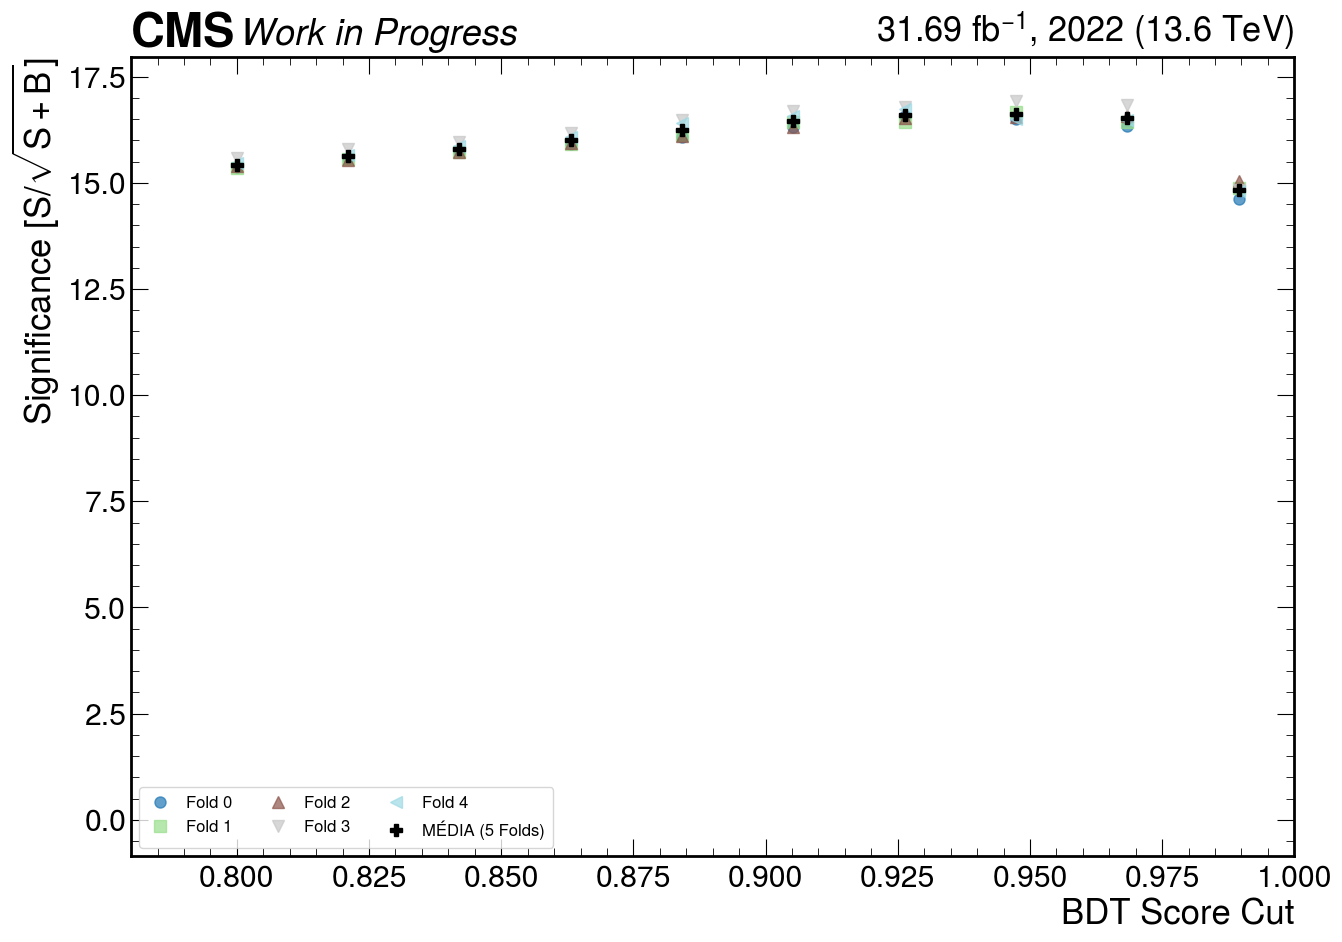

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import zfit
from zfit.loss import UnbinnedNLL
from zfit.minimize import Minuit 
import mplhep as hep
import os
import pandas as pd

# Estilo CMS
hep.style.use("CMS")

if not os.path.exists("PlotsEE"):
    os.makedirs("PlotsEE")

all_fom_curves = []
all_cuts = np.linspace(0.8, 1, 20) # Mantenha o range que desejar

for i in range(5):
    df = df_final[df_final["fold_id"] == i]
    mass_min_lsb, mass_max_lsb = 5.0, 5.133542769
    mass_min_rsb, mass_max_rsb = 5.416657231, 5.6
    
    obs_lsb = zfit.Space("BToTrkTrkMuMu_fit_mass_Kpi", limits=(mass_min_lsb, mass_max_lsb))
    obs_rsb = zfit.Space("BToTrkTrkMuMu_fit_mass_Kpi", limits=(mass_min_rsb, mass_max_rsb))
    obs_bkg = obs_lsb + obs_rsb
    
    mask_sidebands = (df['label'] == 0) & (df['bdt_score'] > corte_bdt)
    data_sidebands_np = df[mask_sidebands]['BToTrkTrkMuMu_fit_mass_Kpi'].to_numpy()
    
    data_zfit = zfit.Data.from_numpy(obs=obs_bkg, array=data_sidebands_np)

    lambda_bkg = zfit.Parameter(f"lambda_bkg_f{i}", -0.5, -10.0, 100.0)
    bkg_model = zfit.pdf.Exponential(lambda_=lambda_bkg, obs=obs_bkg)
    
    loss = UnbinnedNLL(model=bkg_model, data=data_zfit)
    minimizer = Minuit()
    result = minimizer.minimize(loss)
    
    result.hesse()
    print(f"Resultado do Fit Fold {i}:\n{result}")

    # Plot do Fit individual (opcional, mantido conforme seu código)
    plt.figure(figsize=(10, 8))
    nbins = 60
    counts, bin_edges = np.histogram(data_sidebands_np, bins=nbins, range=(mass_min_lsb, mass_max_rsb))
    bin_width = bin_edges[1] - bin_edges[0]
    hep.histplot(counts, bins=bin_edges, yerr=True, color='black', histtype='errorbar', label='Data Sidebands')
    x_plot = np.linspace(mass_min_lsb, mass_max_rsb, 1000)
    pdf_values = bkg_model.pdf(x_plot).numpy()
    plt.plot(x_plot, pdf_values * len(data_sidebands_np) * bin_width, color='red', lw=3, label='Background Fit (Exp)')
    plt.axvspan(mass_max_lsb, mass_min_rsb, color='gray', alpha=0.2, label='Signal Region (Blinded)')
    plt.xlabel(r'$m(K^{+}\pi^{-}\mu^{+}\mu^{-})\;[\mathrm{GeV}]$')
    plt.ylabel(f"Events / {bin_width:.3f} GeV")
    hep.cms.label(label="Preliminary", data=True, lumi=L_data_fb, year=2022, com=13.6)
    plt.savefig(f"PlotsEE/Fit_Background_regions{i}.png")
    plt.close()

    # --- BDT SCAN ---
    def integral_exp(lmbda, a, b):
        if abs(lmbda) < 1e-12: return b - a
        return (np.exp(lmbda * b) - np.exp(lmbda * a)) / lmbda

    mass_min_sig, mass_max_sig = 5.133542769, 5.416657231
    FoM_list = []
    
    print(f"Iniciando BDT Scan para Fold {i}...")
    for idx, cut_value in enumerate(all_cuts):
        df_cut = df[df["bdt_score"] > cut_value]
        
        mask_bkg = (df_cut["label"] == 0) & (
            ((df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] >= mass_min_lsb) & (df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] <= mass_max_lsb)) |
            ((df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] >= mass_min_rsb) & (df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] <= mass_max_rsb))
        )
        N_bkg_sb = len(df_cut[mask_bkg])
        
        mask_sig = (df_cut["label"] == 1) & (df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] >= mass_min_sig) & (df_cut["BToTrkTrkMuMu_fit_mass_Kpi"] <= mass_max_sig)
        S_est = len(df_cut[mask_sig]) * scale_factor
        
        if N_bkg_sb < 15:
            FoM_list.append(0.0)
            continue
            
        tau_param = zfit.Parameter(f"tau_f{i}_c{idx}", -1.0, -20.0, 0.0)
        model_bkg_scan = zfit.pdf.Exponential(lambda_=tau_param, obs=obs_bkg)
        data_zfit_scan = zfit.Data.from_numpy(obs=obs_bkg, array=df_cut[mask_bkg]["BToTrkTrkMuMu_fit_mass_Kpi"].to_numpy())
        loss_scan = UnbinnedNLL(model=model_bkg_scan, data=data_zfit_scan)
        minimizer_scan = Minuit()
        result_scan = minimizer_scan.minimize(loss_scan)
        
        tau_val = float(tau_param.value())
        num = integral_exp(tau_val, mass_min_sig, mass_max_sig)
        den = integral_exp(tau_val, mass_min_lsb, mass_max_lsb) + integral_exp(tau_val, mass_min_rsb, mass_max_rsb)
        
        B_est = N_bkg_sb * (num / den)
        fom = S_est / np.sqrt(S_est + B_est) if (S_est + B_est) > 0 else 0.0
        FoM_list.append(fom)

    all_fom_curves.append(np.array(FoM_list))

# --- PROCESSAMENTO DOS RESULTADOS ---
all_fom_array = np.array(all_fom_curves)
fom_mean = np.mean(all_fom_array, axis=0)

# Tabela de Melhores Valores
res_data = []
for i in range(5):
    best_idx = np.argmax(all_fom_curves[i])
    res_data.append({"Fold": i, "Best Cut": all_cuts[best_idx], "Max FoM": all_fom_curves[i][best_idx]})

df_summary = pd.DataFrame(res_data)
print("\n" + "="*40)
print(f"{'RESUMO DE OTIMIZAÇÃO POR FOLD':^40}")
print("="*40)
print(df_summary.to_string(index=False))
print("="*40)

# --- PLOT FINAL ---
fig, ax = plt.subplots(figsize=(14, 10))
colors = plt.cm.tab20(np.linspace(0, 1, 5))
markers = ['o', 's', '^', 'v', '<', '>', 'p', '*', 'h', 'D', 'X']

# Plotar cada fold
for i in range(5):
    ax.plot(all_cuts, all_fom_curves[i], 
            label=f"Fold {i}", 
            color=colors[i], 
            marker=markers[i], 
            markevery=2, 
            markersize=8, 
            lw=0, 
            alpha=0.7)

# Plotar a MÉDIA
ax.plot(all_cuts, fom_mean, 
        label="MÉDIA (5 Folds)", 
        color='black', 
        marker='P', 
        markevery=2, 
        markersize=8, 
        lw=0, 
        zorder=20)

ax.set_xlabel("BDT Score Cut", fontsize=25)
ax.set_ylabel(r"Significance $[S/\sqrt{S+B}]$", fontsize=25)
ax.set_xlim(0.78, 1.0)
ax.legend(loc='lower left', fontsize=12, ncol=3, frameon=True)
hep.cms.label(ax=ax, label="Work in Progress", data=True, lumi=L_data_fb, year="2022", com=13.6)

plt.tight_layout()
plt.savefig("PlotsEE/BDT_Optimization_Comparison_Full.png", dpi=300)
plt.show()

In [21]:
import pandas as pd

# 1. Criar a tabela detalhada (Valores de FoM para cada corte em cada fold)
# Transformamos a lista de arrays em uma matriz e transpomos para os cortes serem as linhas
df_fom_detalhado = pd.DataFrame(
    np.array(all_fom_curves).T, 
    columns=[f"Fold_{i}" for i in range(5)], 
    index=all_cuts
)
df_fom_detalhado.index.name = "BDT_Cut"

# 2. Criar a tabela de resumo (Best Cut e Max FoM para cada fold)
resumo_data = []
for i in range(5):
    idx_max = np.argmax(all_fom_curves[i])
    resumo_data.append({
        "Fold": i,
        "Best_Cut": all_cuts[idx_max],
        "Max_FoM": all_fom_curves[i][idx_max]
    })
df_resumo = pd.DataFrame(resumo_data)

# --- PRINTS DOS RESULTADOS ---

print("\n" + "="*80)
print(f"{'TABELA COMPLETA: VALORES DE FoM POR CORTE E MODELO':^80}")
print("="*80)
# Mostra todos os 20 cortes (ou o número de cortes que você definiu em all_cuts)
print(df_fom_detalhado.round(4).to_string()) 

print("\n" + "="*50)
print(f"{'RESUMO: MELHORES CORTES ENCONTRADOS':^50}")
print("="*50)
print(df_resumo.to_string(index=False, formatters={'Best_Cut': '{:,.4f}'.format, 'Max_FoM': '{:,.4f}'.format}))
print("="*50)

# Opcional: Salvar em CSV caso queira abrir no Excel depois
df_fom_detalhado.to_csv("PlotsEE/tabela_fom_detalhada.csv")
df_resumo.to_csv("PlotsEE/tabela_best_cuts.csv", index=False)


               TABELA COMPLETA: VALORES DE FoM POR CORTE E MODELO               
           Fold_0   Fold_1   Fold_2   Fold_3   Fold_4
BDT_Cut                                              
0.800000  15.3623  15.3576  15.3858  15.5877  15.4618
0.810526  15.4564  15.4827  15.4420  15.7026  15.5315
0.821053  15.5741  15.5521  15.5384  15.8079  15.6662
0.831579  15.7369  15.6623  15.6464  15.8271  15.7542
0.842105  15.7562  15.7151  15.7302  15.9617  15.8569
0.852632  15.8099  15.7677  15.8653  16.1070  16.0313
0.863158  15.9182  15.9148  15.9464  16.1844  16.0863
0.873684  16.0920  15.9994  15.9864  16.3623  16.2891
0.884211  16.0714  16.1263  16.1095  16.4742  16.4081
0.894737  16.2332  16.3014  16.2153  16.5508  16.5392
0.905263  16.3235  16.4270  16.3087  16.6842  16.5728
0.915789  16.4254  16.4305  16.4290  16.7991  16.5945
0.926316  16.5667  16.4436  16.5253  16.7829  16.7299
0.936842  16.5813  16.5722  16.5246  16.9372  16.6621
0.947368  16.5020  16.6757  16.5498  16.9252  16.5024
